In [3]:

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
exchange_rates = pd.read_csv("euro-daily-hist_1999_2020.csv")

In [5]:
exchange_rates.head(5)

,Period\Unit:,[Australian dollar ],[Bulgarian lev ],[Brazilian real ],[Canadian dollar ],[Swiss franc ],[Chinese yuan renminbi ],[Cypriot pound ],[Czech koruna ],[Danish krone ],...,[Romanian leu ],[Russian rouble ],[Swedish krona ],[Singapore dollar ],[Slovenian tolar ],[Slovak koruna ],[Thai baht ],[Turkish lira ],[US dollar ],[South African rand ]
0,2021-01-08,1.5758,1.9558,6.5748,1.5543,1.0827,7.9184,NaN,26.163,7.4369,...,4.8708,90.8000,10.0510,1.6228,NaN,NaN,36.8480,9.0146,1.2250,18.7212
1,2021-01-07,1.5836,1.9558,6.5172,1.5601,1.0833,7.9392,NaN,26.147,7.4392,...,4.8712,91.2000,10.0575,1.6253,NaN,NaN,36.8590,8.9987,1.2276,18.7919
2,2021-01-06,1.5824,1.9558,6.5119,1.5640,1.0821,7.9653,NaN,26.145,7.4393,...,4.8720,90.8175,10.0653,1.6246,NaN,NaN,36.9210,9.0554,1.2338,18.5123
3,2021-01-05,1.5927,1.9558,6.5517,1.5651,1.0803,7.9315,NaN,26.227,7.4387,...,4.8721,91.6715,10.0570,1.6180,NaN,NaN,36.7760,9.0694,1.2271,18.4194
4,2021-01-04,1.5928,1.9558,6.3241,1.5621,1.0811,7.9484,NaN,26.141,7.4379,...,4.8713,90.3420,10.0895,1.6198,NaN,NaN,36.7280,9.0579,1.2296,17.9214


In [6]:
exchange_rates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5699 entries, 0 to 5698
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Period\Unit:              5699 non-null   object 
 1   [Australian dollar ]      5699 non-null   object 
 2   [Bulgarian lev ]          5297 non-null   object 
 3   [Brazilian real ]         5431 non-null   object 
 4   [Canadian dollar ]        5699 non-null   object 
 5   [Swiss franc ]            5699 non-null   object 
 6   [Chinese yuan renminbi ]  5431 non-null   object 
 7   [Cypriot pound ]          2346 non-null   object 
 8   [Czech koruna ]           5699 non-null   object 
 9   [Danish krone ]           5699 non-null   object 
 10  [Estonian kroon ]         3130 non-null   object 
 11  [UK pound sterling ]      5699 non-null   object 
 12  [Greek drachma ]          520 non-null    object 
 13  [Hong Kong dollar ]       5699 non-null   object 
 14  [Croatia

1. Rows = 5699, columns = 40  
2. We don't see  null values but we can see Nan values in  some columns 
3. Most columns are of type object, but some are of type float64.

In [7]:
exchange_rates.rename(columns={'[US dollar ]':'US_dollar',
                               'Period\\Unit:': 'Time'},inplace=True)
exchange_rates['Time'] = pd.to_datetime(exchange_rates['Time'])
exchange_rates.sort_values('Time',inplace=True)
exchange_rates.reset_index(drop=True,inplace=True)



In [8]:
euro_to_dollar = exchange_rates.loc[:,['Time', 'US_dollar']]
euro_to_dollar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5699 entries, 0 to 5698
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Time       5699 non-null   datetime64[ns]
 1   US_dollar  5699 non-null   object        
dtypes: datetime64[ns](1), object(1)
memory usage: 89.2+ KB


In [9]:
euro_to_dollar['US_dollar'].value_counts()


US_dollar
-         62
1.2276     9
1.1215     8
1.1305     7
1.0867     6
          ..
1.1869     1
1.1752     1
1.1770     1
1.1750     1
1.1821     1
Name: count, Length: 3528, dtype: int64

In [10]:
euro_to_dollar['US_dollar'] =pd.to_numeric(euro_to_dollar['US_dollar'],errors='coerce')

errors='coerce'  helps us convert avoiding incorrect data types 

In [11]:
euro_to_dollar['US_dollar'].info() 

<class 'pandas.core.series.Series'>
RangeIndex: 5699 entries, 0 to 5698
Series name: US_dollar
Non-Null Count  Dtype  
--------------  -----  
5637 non-null   float64
dtypes: float64(1)
memory usage: 44.6 KB


In [23]:
euro_to_dollar['rolling_mean'] = euro_to_dollar['US_dollar'].rolling(30).mean()

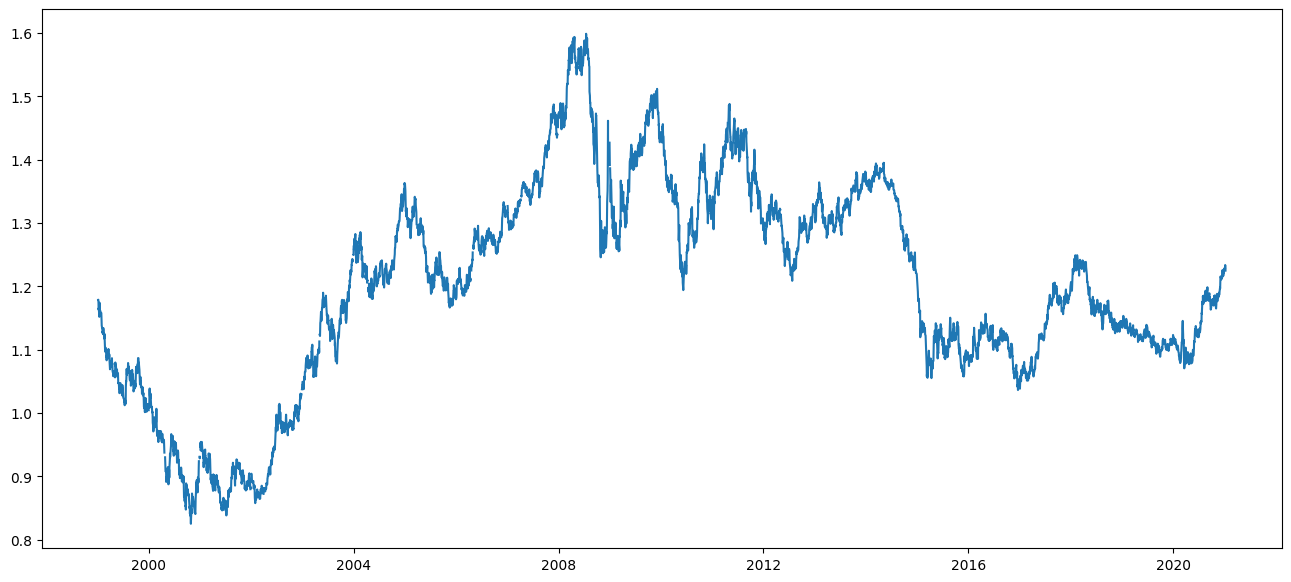

In [28]:
plt.figure(figsize=(16,7))
plt.plot(euro_to_dollar['Time'],
         euro_to_dollar['US_dollar'])
plt.show()

We show how the euro-dollar rate changed during the 2007-2008 financial crisis. We can also show the data for 2006 and 2009 for comparison. We can use a line plot.

In [29]:
df_2006_2009=euro_to_dollar[(euro_to_dollar['Time'] >= pd.Timestamp("2007-01-01")) & (euro_to_dollar['Time'] <= pd.Timestamp("2009-01-31"))]



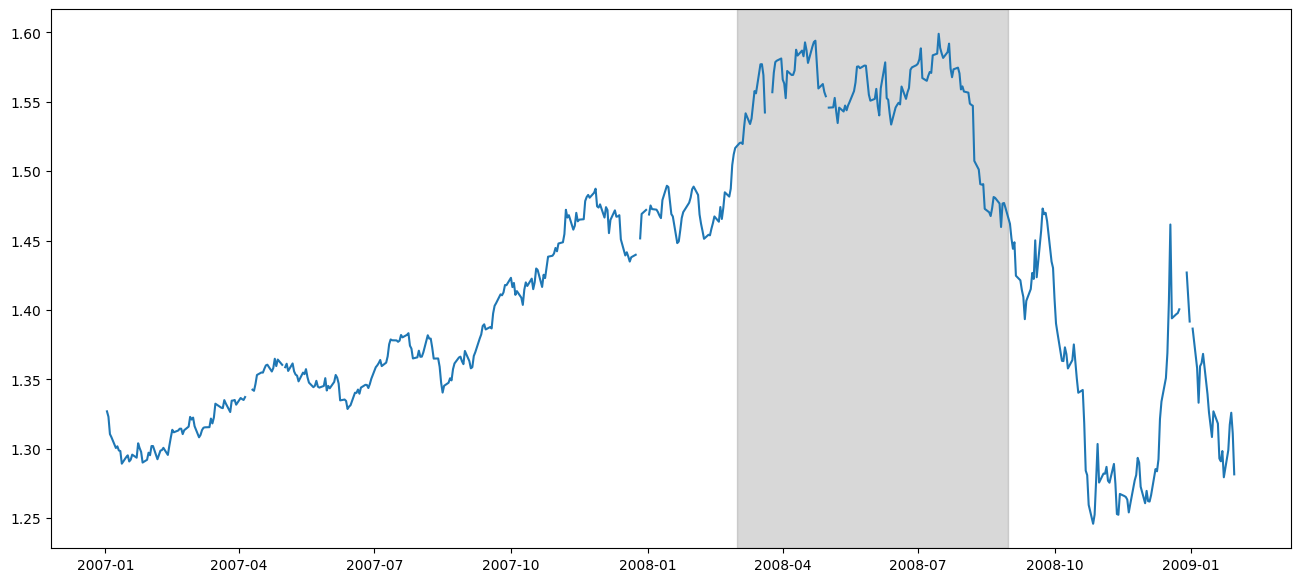

In [42]:
plt.figure(figsize=(16,7))
plt.plot(df_2006_2009['Time'],
         df_2006_2009['US_dollar'])
A = '2008-03-01'
B = '2008-08-31'
plt.axvspan(A, B, color='gray', alpha=0.3)
plt.show()


As we can see during the 2007-2009 crisis, the dollar-euro correlation increased from 1.30 to 1.6 as a peak value.

Well, after 2008-08-31, the situation began to stabilize and the dollar began to strengthen.